This notebook was developed to compare PCA representations across different calibration datasets by reconstructing hidden activations using principal components from other datasets and analyzing the resulting reconstruction quality across layers.

The hidden states can be accessed from the specified directory in the cells. Before running the notebook, make sure to add the shared Google Drive folder to your “My Drive” using the provided link (https://drive.google.com/drive/folders/1VRkguTVtRkllTlSID9ugy4MHwCacsE_K?usp=sharing). 

To do this:
1. Open the shared folder link.
2. Click on “Add shortcut to Drive”.
3. Select “My Drive” as the destination.

After that, the folder will be accessible in Colab through the mounted Google Drive (e.g., /content/drive/MyDrive/...), allowing the hidden states to be loaded directly.

In [1]:
from google.colab import drive
drive.mount("/content/drive")

Mounted at /content/drive


In [2]:
import os, textwrap

# Where to save logs and models in your Drive
BASE_RESULTS_DIR = "/content/drive/MyDrive/TUM/Pratikum/SliceGPTExperiments"
LOG_DIR = os.path.join(BASE_RESULTS_DIR, "logs_opt_pca/Qwen2-0.5B")
MODEL_DIR = os.path.join(BASE_RESULTS_DIR, "models_opt_pca/Qwen2-0.5B")
EVAL_DIR = os.path.join(BASE_RESULTS_DIR, "eval")

os.makedirs(LOG_DIR, exist_ok=True)
os.makedirs(MODEL_DIR, exist_ok=True)
os.makedirs(EVAL_DIR, exist_ok=True)

In [ ]:
SQUAD_HIDDEN = os.path.join(MODEL_DIR, "squad_s0p00/Qwen2-0.5B_0.0_squad_hidden_states.pt")
WIKI_HIDDEN = os.path.join(MODEL_DIR, "wikitext2_s0p00/Qwen2-0.5B_0.0_wikitext2_hidden_states.pt")
# COQA_HIDDEN = os.path.join(MODEL_DIR, "coqa_s0p00/Qwen2-0.5B_0.0_coqa_hidden_states.pt")
SQUAD_ROT = os.path.join(MODEL_DIR,"squad_s0p00/Qwen2-0.5B_0.0_rotation_matrices.pt")
WIKI_ROT = os.path.join(MODEL_DIR,"wikitext2_s0p00/Qwen2-0.5B_0.0_rotation_matrices.pt")
# COQA_ROT = os.path.join(MODEL_DIR,"coqa_s0p00/Qwen2-0.5B_0.0_rotation_matrices.pt")

COQA_HIDDEN = "/content/drive/MyDrive/TUM/temp/qwen_coqa/Qwen2-0.5B_0.0_coqa_hidden_states.pt"
COQA_ROT = "/content/drive/MyDrive/TUM/temp/qwen_coqa/Qwen2-0.5B_0.0_rotation_matrices.pt"

In [3]:
import torch
import numpy as np

In [ ]:
pcas_squad = torch.load(SQUAD_ROT)
pcas_wikitext = torch.load(WIKI_ROT)

In [ ]:
pcas_wikitext

In [ ]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

In [ ]:
def get_pca_entry(pcas, layer_index, layer_type):
    valid_types = ['attn_output', 'mlp_output', 'embedding']
    if layer_type not in valid_types:
        raise ValueError(f"layer_type must be one of {valid_types}, got '{layer_type}'")

    for entry in pcas:
        if entry['type'] == layer_type and entry['layer'] == layer_index:
            return entry

    raise ValueError(f"No PCA entry found for layer_type='{layer_type}', layer={layer_index}")

In [ ]:
def load_hidden_states(hs_dir, layer_index, layer_type, verbose=False):
    layer_key = f"layer_{layer_index}_{layer_type}"

    squad_hs_path = os.path.join(hs_dir, "squad_s0p00", f"Qwen2-0.5B_0.0_squad_hs_{layer_key}.pt")
    squad_hs = torch.load(squad_hs_path)
    if verbose:
        print("Loaded squad hidden states.")

    wikitext_hs_path = os.path.join(hs_dir, "wikitext2_s0p00", f"Qwen2-0.5B_0.0_wikitext2_hs_{layer_key}.pt")
    wikitext_hs = torch.load(wikitext_hs_path)
    if verbose:
        print("Loaded wikitext hidden states.")

    return {"squad": squad_hs, "wikitext": wikitext_hs}

In [ ]:
def compute_pca(activations):
    H = activations.T @ activations
    computed_eigenvalues, computed_eigenvectors = torch.linalg.eigh(H)
    return computed_eigenvalues, computed_eigenvectors

In [ ]:
def calculate_explained_variance(activations, eigenvectors, centered=True):
    if centered:
        mean = activations.mean(dim=0)
        activations_centered = activations - mean
    else:
        mean = 0
        activations_centered = activations

    projected = activations_centered @ eigenvectors
    reconstructed = projected @ eigenvectors.T

    # Calculate error in centered space
    total_variance = torch.sum(activations_centered ** 2)
    reconstruction_error = torch.sum((activations_centered - reconstructed) ** 2)
    explained_variance = 1 - (reconstruction_error / total_variance)

    return explained_variance

In [ ]:
# pca calc function from slicegpt

def pca_calc(
    X: list[torch.Tensor], ignore_masks: list[torch.Tensor] | None = None
) -> tuple[torch.Tensor, torch.Tensor]:
    """
    Run PCA on a list of batched data. Returns the eigenvalues and eigenvectors.
    """

    H = None
    for idx, X_batch in enumerate(X):
        if ignore_masks:
            X_batch[ignore_masks[idx] == 0] = 0

        X_batch = X_batch.double().to(device=device)
        H_batch = torch.sum(X_batch.mT @ X_batch, dim=0)  # sum over the batch dimension.
        H = H_batch if H is None else H + H_batch

    damp = 0.01 * torch.mean(torch.diag(H))
    diag = torch.arange(H.shape[-1]).to(device=device)
    H[diag, diag] = H[diag, diag] + damp
    X_eig = torch.linalg.eigh(H)
    del H
    index = torch.argsort(X_eig[0], descending=True)
    eig_val = X_eig[0][index]
    eigen_vec = X_eig[1][:, index]
    return eig_val, eigen_vec

In [ ]:
def get_explained_variances(hs_dir, layer_index, layer_type, sparsity=0.25, verbose=False, centered=True):
    layer_key = f"layer_{layer_index}_{layer_type}"

    # load activations
    hidden_states = load_hidden_states(hs_dir, layer_index, layer_type, verbose=verbose)

    # recomputing PCA to ensure it matches data
    squad_eigval, squad_eigvec = pca_calc(hidden_states["squad"])
    wikitext_eigval, wikitext_eigvec = pca_calc(hidden_states["wikitext"])

    # concatenate batches and sequence tokens
    squad_activations_flat = torch.cat([act.reshape(-1, act.shape[-1]) for act in hidden_states["squad"]])
    wiki_activations_flat = torch.cat([act.reshape(-1, act.shape[-1]) for act in hidden_states["wikitext"]])

    squad_activations_flat = squad_activations_flat.double().to(device)
    wiki_activations_flat = wiki_activations_flat.double().to(device)

    # projecting and reconstructing
    k = int(squad_activations_flat.shape[1] * (1 - sparsity))

    if verbose:
        print("Calculating variances (Uncentered/Energy)..." if not centered else "Calculating variances (Centered)...")

    explained_variances = {
        "squad_projto_squad": calculate_explained_variance(squad_activations_flat, squad_eigvec[:, :k], centered=centered),
        "squad_projto_wikitext": calculate_explained_variance(squad_activations_flat, wikitext_eigvec[:, :k], centered=centered),
        "wikitext_projto_squad": calculate_explained_variance(wiki_activations_flat, squad_eigvec[:, :k], centered=centered),
        "wikitext_projto_wikitext": calculate_explained_variance(wiki_activations_flat, wikitext_eigvec[:, :k], centered=centered)
    }
    if verbose:
        print("Done.")

    return explained_variances

In [ ]:
get_explained_variances(MODEL_DIR, 0, "mlp_output", centered=True)

{'squad_projto_squad': tensor(0.9807, device='cuda:0', dtype=torch.float64),
 'squad_projto_wikitext': tensor(0.9731, device='cuda:0', dtype=torch.float64),
 'wikitext_projto_squad': tensor(0.9731, device='cuda:0', dtype=torch.float64),
 'wikitext_projto_wikitext': tensor(0.9814, device='cuda:0', dtype=torch.float64)}

In [ ]:
get_explained_variances(MODEL_DIR, 0, "mlp_output", centered=False)

{'squad_projto_squad': tensor(0.9823, device='cuda:0', dtype=torch.float64),
 'squad_projto_wikitext': tensor(0.9751, device='cuda:0', dtype=torch.float64),
 'wikitext_projto_squad': tensor(0.9752, device='cuda:0', dtype=torch.float64),
 'wikitext_projto_wikitext': tensor(0.9830, device='cuda:0', dtype=torch.float64)}

In [ ]:
from tqdm import tqdm

def get_explained_variances_by_layer(layer_type, sparsity):
    squad_to_squad = []
    squad_to_wikitext = []
    wikitext_to_squad = []
    wikitext_to_wikitext = []

    for layer_index in tqdm(range(24)):
        variances = get_explained_variances(MODEL_DIR,
                                            layer_index,
                                            layer_type,
                                            sparsity=sparsity)

        squad_to_squad.append(variances["squad_projto_squad"])
        squad_to_wikitext.append(variances["squad_projto_wikitext"])
        wikitext_to_squad.append(variances["wikitext_projto_squad"])
        wikitext_to_wikitext.append(variances["wikitext_projto_wikitext"])

    squad_to_squad = torch.cat([x.reshape(1, -1) for x in squad_to_squad]).reshape(-1).cpu()
    squad_to_wikitext = torch.cat([x.reshape(1, -1) for x in squad_to_wikitext]).reshape(-1).cpu()
    wikitext_to_squad = torch.cat([x.reshape(1, -1) for x in wikitext_to_squad]).reshape(-1).cpu()
    wikitext_to_wikitext = torch.cat([x.reshape(1, -1) for x in wikitext_to_wikitext]).reshape(-1).cpu()

    explained_variances = {
        "squad_projto_squad": squad_to_squad,
        "squad_projto_wikitext": squad_to_wikitext,
        "wikitext_projto_squad": wikitext_to_squad,
        "wikitext_projto_wikitext": wikitext_to_wikitext
    }

    return explained_variances

In [ ]:
from datetime import datetime

explained_variances = {
    "metadata": {
        "model": "Qwen2-0.5B",
        "date": datetime.now().strftime("%Y-%m-%d %H:%M:%S"),
        "desc": "Comparison of hidden activations from slicing on squad/wikitext projected and reconstructed using squad/wikitext PCs."
    }
}

save_path = os.path.join(EVAL_DIR, "Qwen2-0.5B-pca-comparison", "explained_variances.pt")
os.makedirs(os.path.dirname(save_path), exist_ok=True)

for layer_type in ["attn_output", "mlp_output"]:
    for sparsity in [0.1, 0.25, 0.4, 0.6]:
        print(f"Calculating explained variances. layer type = {layer_type} - sparsity = {sparsity}")

        explained_variances[f"{layer_type}_{sparsity}"] = get_explained_variances_by_layer(layer_type, sparsity)

        torch.save(explained_variances, save_path)

Calculating explained variances. layer type = attn_output - sparsity = 0.1


100%|██████████| 24/24 [05:05<00:00, 12.72s/it]


Calculating explained variances. layer type = attn_output - sparsity = 0.25


100%|██████████| 24/24 [04:37<00:00, 11.55s/it]


Calculating explained variances. layer type = attn_output - sparsity = 0.4


...

100%|██████████| 24/24 [04:39<00:00, 11.65s/it]


Calculating explained variances. layer type = mlp_output - sparsity = 0.4


100%|██████████| 24/24 [04:11<00:00, 10.47s/it]


Calculating explained variances. layer type = mlp_output - sparsity = 0.6


 12%|█▎        | 3/24 [00:25<03:01,  8.63s/it]

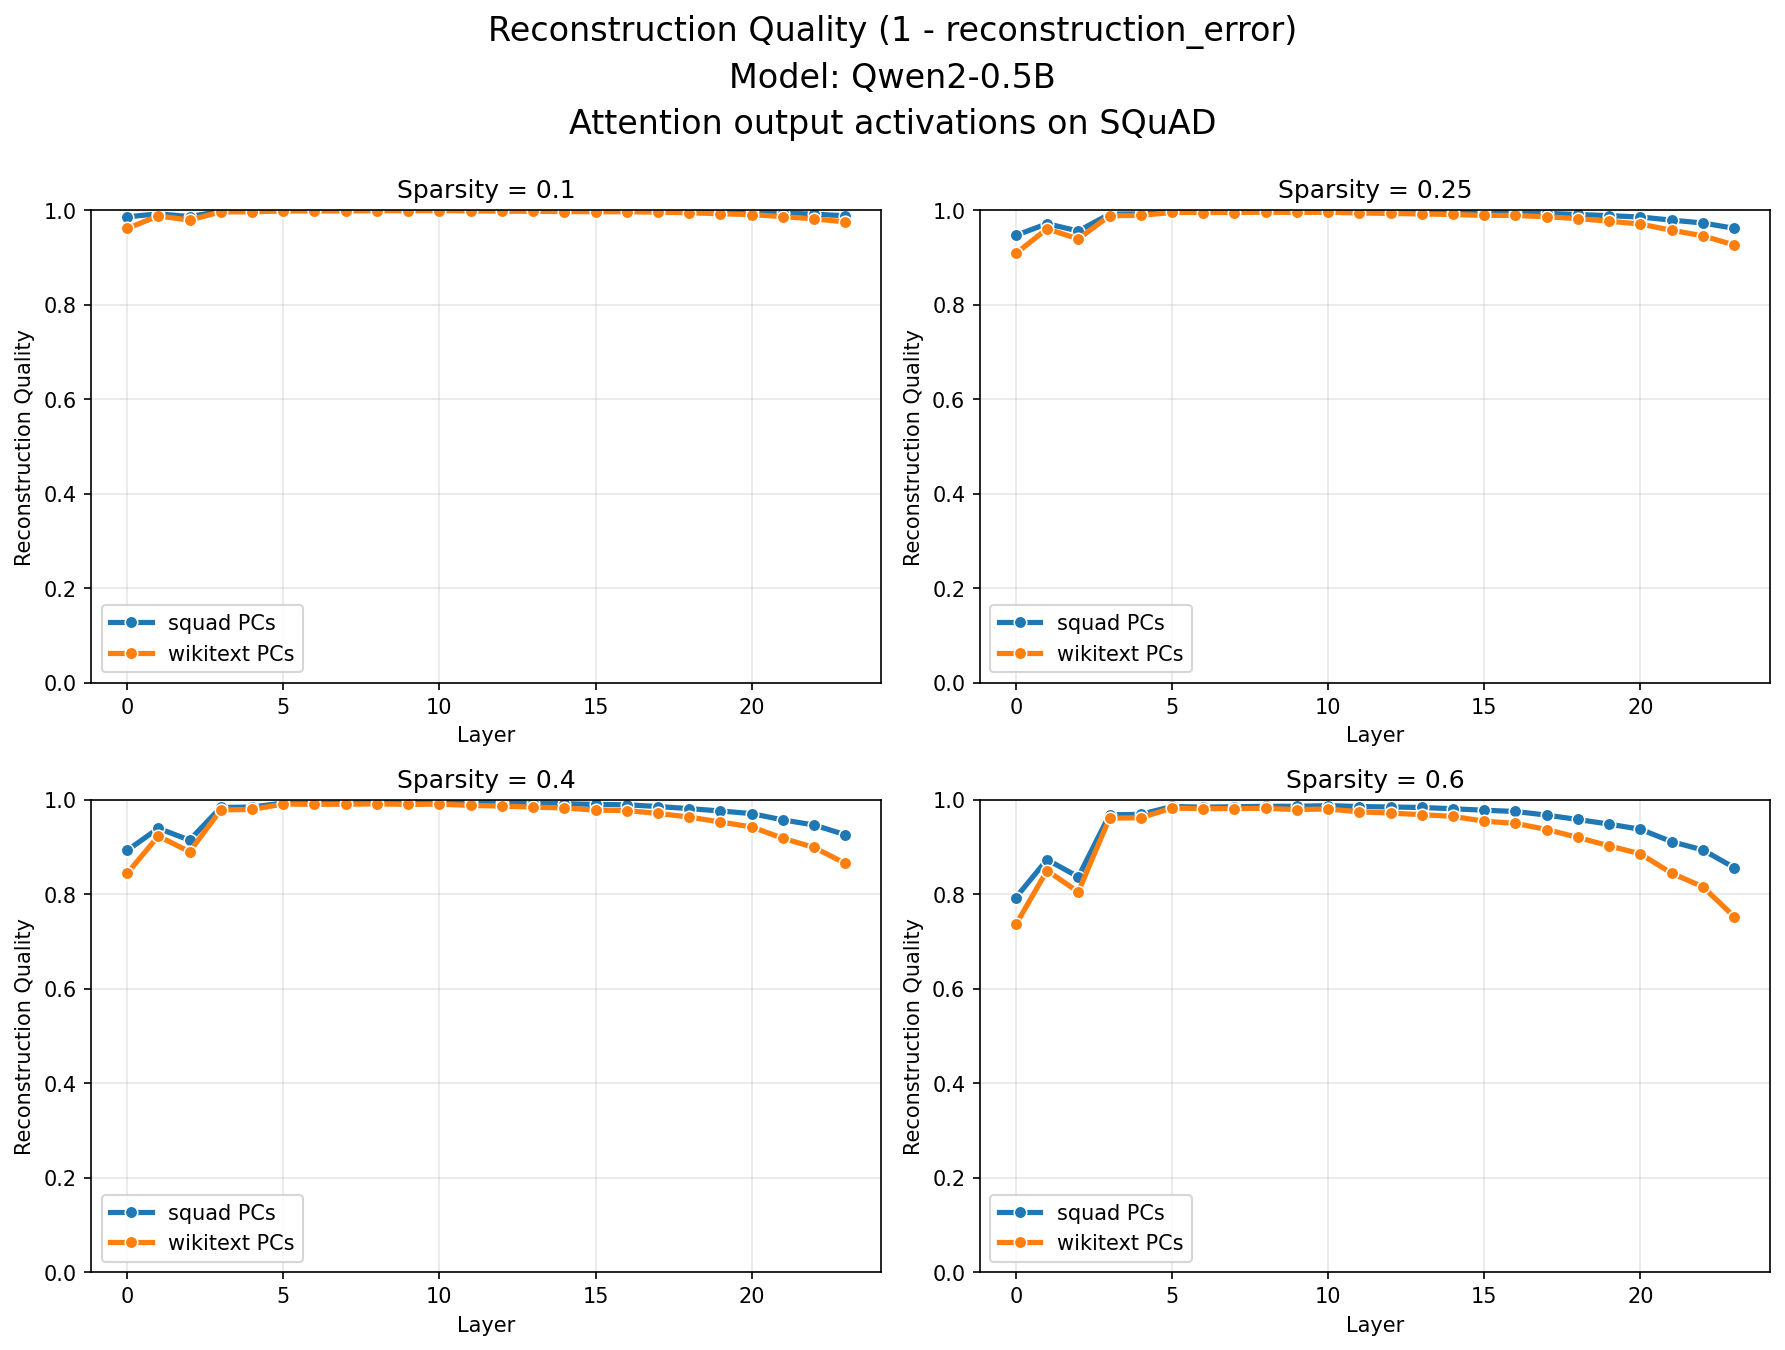

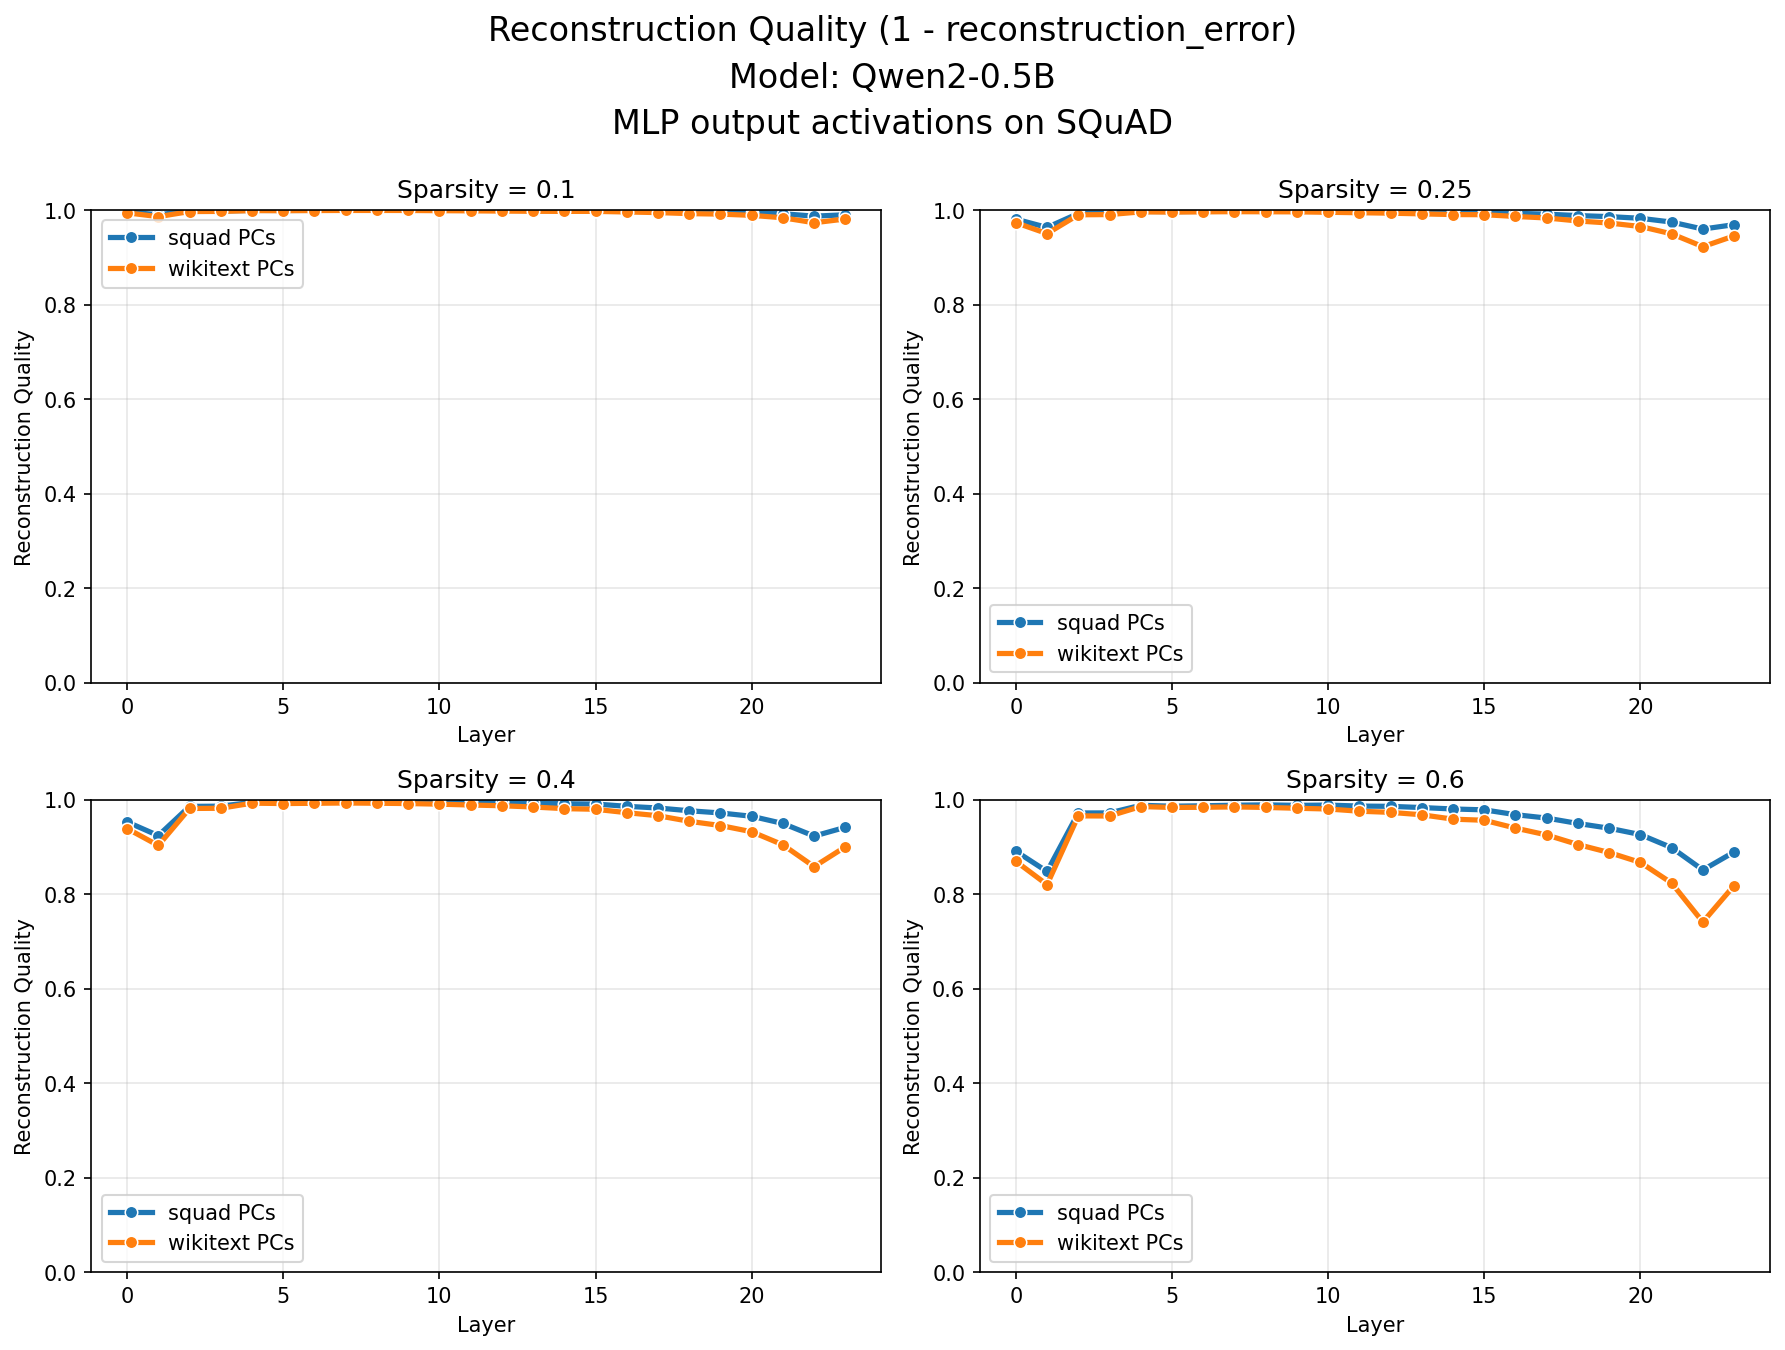

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

N_LAYERS = 24

for layer_type in ["attn_output", "mlp_output"]:

    layer_type_text = {
        "attn_output": "Attention output",
        "mlp_output": "MLP output"
        }[layer_type]

    fig, axes = plt.subplots(2, 2, figsize=(12, 9), dpi=150)
    fig.suptitle(f'Reconstruction Quality (1 - reconstruction_error)\n'
                 f'Model: {explained_variances["metadata"]["model"]}\n'
                 f'{layer_type_text} activations on SQuAD',
                 fontsize=16,
                 linespacing=1.5,
                 y=0.995)

    axes = axes.flatten()

    for idx, sparsity in enumerate([0.1, 0.25, 0.4, 0.6]):
        ax = axes[idx]

        key = f"{layer_type}_{sparsity}"
        data = explained_variances[key]

        layers = range(N_LAYERS)

        sns.lineplot(x=list(range(24)),
                     y=data["squad_projto_squad"],
                     label="squad PCs",
                     marker='o',
                     linewidth=2.5,
                     ax=ax)
        sns.lineplot(x=list(range(24)),
                     y=data["squad_projto_wikitext"],
                     label="wikitext PCs",
                     marker='o',
                     linewidth=2.5,
                     ax=ax)
        ax.set_title(f"Sparsity = {sparsity}")
        ax.set_xlabel("Layer")
        ax.set_ylabel("Reconstruction Quality")
        ax.grid(True, alpha=0.3)
        ax.set_ylim([0, 1.0])
        ax.legend()

    plt.tight_layout()
    plt.show()

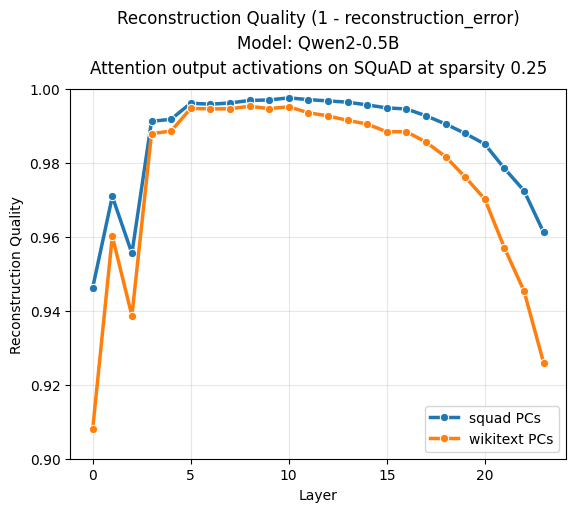

In [ ]:
data = explained_variances["attn_output_0.25"]

sns.lineplot(x=list(range(24)),
                y=data["squad_projto_squad"],
                label="squad PCs",
                marker='o',
                linewidth=2.5)
sns.lineplot(x=list(range(24)),
                y=data["squad_projto_wikitext"],
                label="wikitext PCs",
                marker='o',
                linewidth=2.5)
plt.title(f'Reconstruction Quality (1 - reconstruction_error)\n'
                 f'Model: {explained_variances["metadata"]["model"]}\n'
                 f'Attention output activations on SQuAD at sparsity 0.25',
                 fontsize=12,
                 linespacing=1.5,
                 y=1.02)
plt.xlabel("Layer")
plt.ylabel("Reconstruction Quality")
plt.grid(True, alpha=0.3)
plt.ylim([0.9, 1.0])
plt.legend()

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
from tqdm import tqdm

squad_to_squad = []
squad_to_wikitext = []
wikitext_to_squad = []
wikitext_to_wikitext = []

for layer_index in tqdm(range(24)):
    variances = get_explained_variances(MODEL_DIR, layer_index, "attn_output")

    squad_to_squad.append(variances["squad_projto_squad"])
    squad_to_wikitext.append(variances["squad_projto_wikitext"])
    wikitext_to_squad.append(variances["wikitext_projto_squad"])
    wikitext_to_wikitext.append(variances["wikitext_projto_wikitext"])

100%|██████████| 24/24 [09:48<00:00, 24.53s/it]


In [ ]:
squad_to_squad = torch.cat([x.reshape(1, -1) for x in squad_to_squad]).reshape(-1).cpu()
squad_to_wikitext = torch.cat([x.reshape(1, -1) for x in squad_to_wikitext]).reshape(-1).cpu()
wikitext_to_squad = torch.cat([x.reshape(1, -1) for x in wikitext_to_squad]).reshape(-1).cpu()
wikitext_to_wikitext = torch.cat([x.reshape(1, -1) for x in wikitext_to_wikitext]).reshape(-1).cpu()

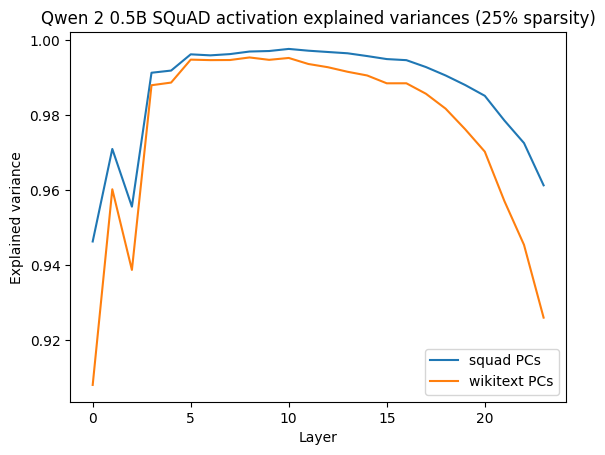

In [ ]:
sns.lineplot(x=list(range(24)), y=squad_to_squad, label="squad PCs")
sns.lineplot(x=list(range(24)), y=squad_to_wikitext, label="wikitext PCs")
plt.title("Qwen 2 0.5B SQuAD activation explained variances (25% sparsity)")
plt.xlabel("Layer")
plt.ylabel("Explained variance")
plt.legend()
plt.show()

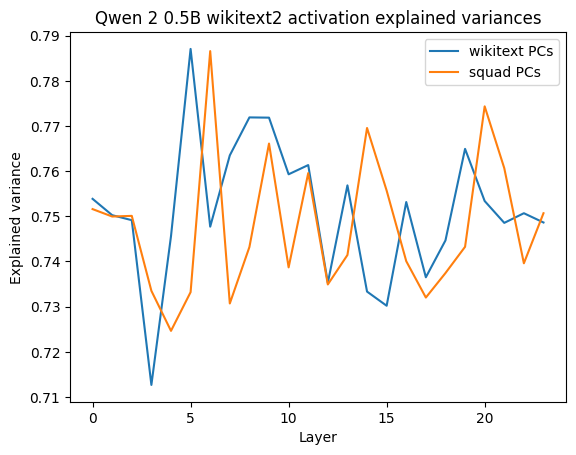

In [ ]:
sns.lineplot(x=list(range(24)), y=wikitext_to_wikitext, label="wikitext PCs")
sns.lineplot(x=list(range(24)), y=wikitext_to_squad, label="squad PCs")
plt.title("Qwen 2 0.5B wikitext2 activation explained variances (25% sparsityb)")
plt.xlabel("Layer")
plt.ylabel("Explained variance")
plt.legend()
plt.show()

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
from tqdm import tqdm

squad_to_squad = []
squad_to_wikitext = []
wikitext_to_squad = []
wikitext_to_wikitext = []

for layer_index in tqdm(range(24)):
    variances = get_explained_variances(MODEL_DIR, layer_index, "attn_output", sparsity=0.6)

    squad_to_squad.append(variances["squad_projto_squad"])
    squad_to_wikitext.append(variances["squad_projto_wikitext"])
    wikitext_to_squad.append(variances["wikitext_projto_squad"])
    wikitext_to_wikitext.append(variances["wikitext_projto_wikitext"])

squad_to_squad = torch.cat([x.reshape(1, -1) for x in squad_to_squad]).reshape(-1).cpu()
squad_to_wikitext = torch.cat([x.reshape(1, -1) for x in squad_to_wikitext]).reshape(-1).cpu()
wikitext_to_squad = torch.cat([x.reshape(1, -1) for x in wikitext_to_squad]).reshape(-1).cpu()
wikitext_to_wikitext = torch.cat([x.reshape(1, -1) for x in wikitext_to_wikitext]).reshape(-1).cpu()

100%|██████████| 24/24 [08:36<00:00, 21.52s/it]


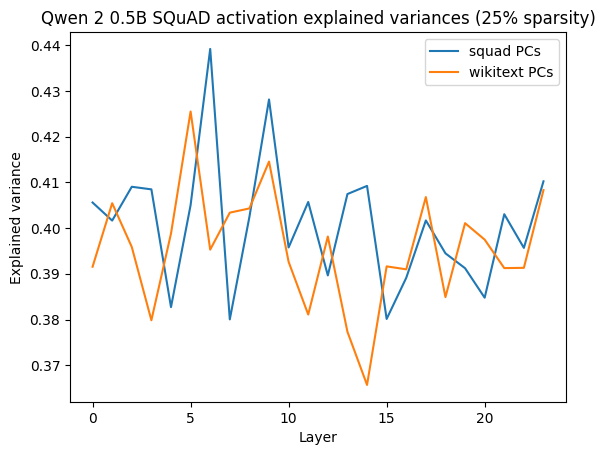

In [ ]:
sns.lineplot(x=list(range(24)), y=squad_to_squad, label="squad PCs")
sns.lineplot(x=list(range(24)), y=squad_to_wikitext, label="wikitext PCs")
plt.title("Qwen 2 0.5B SQuAD activation explained variances (25% sparsity)")
plt.xlabel("Layer")
plt.ylabel("Explained variance")
plt.legend()
plt.show()

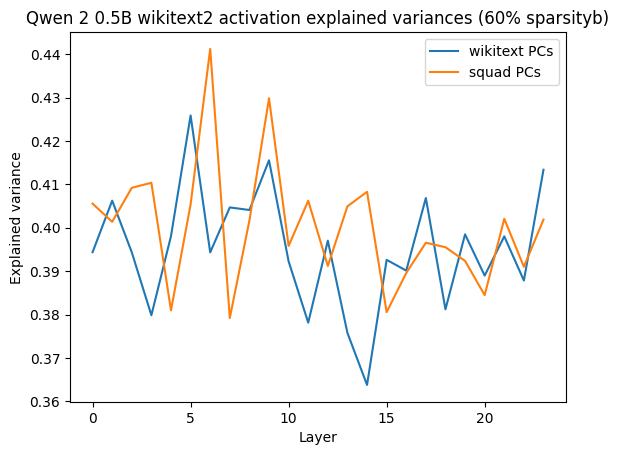

In [ ]:
sns.lineplot(x=list(range(24)), y=wikitext_to_wikitext, label="wikitext PCs")
sns.lineplot(x=list(range(24)), y=wikitext_to_squad, label="squad PCs")
plt.title("Qwen 2 0.5B wikitext2 activation explained variances (60% sparsityb)")
plt.xlabel("Layer")
plt.ylabel("Explained variance")
plt.legend()
plt.show()

In [ ]:
def load_hidden_states(hs_dir, layer_index, layer_type, dataset, verbose=False):
    layer_key = f"layer_{layer_index}_{layer_type}"

    hs_path = os.path.join(hs_dir, f"{dataset}_s0p00", f"Qwen2-0.5B_0.0_{dataset}_hs_{layer_key}.pt")
    hs = torch.load(hs_path)
    if verbose:
        print("Loaded squad hidden states.")

    return hs

In [ ]:
def get_explained_variances(hs_dir,
                            layer_index,
                            layer_type,
                            hs_dataset,
                            pc_dataset1,
                            pc_dataset2,
                            sparsity=0.25,
                            verbose=False,
                            centered=True):
    layer_key = f"layer_{layer_index}_{layer_type}"

    # load activations
    hidden_states_hsd = load_hidden_states(hs_dir,
                                       layer_index,
                                       layer_type,
                                       hs_dataset,
                                       verbose=verbose)

    hidden_states_pcd1 = load_hidden_states(hs_dir,
                                       layer_index,
                                       layer_type,
                                       pc_dataset1,
                                       verbose=verbose)

    hidden_states_pcd2 = load_hidden_states(hs_dir,
                                       layer_index,
                                       layer_type,
                                       pc_dataset2,
                                       verbose=verbose)

    # recomputing PCA to ensure it matches data
    ds1_eigval, ds1_eigvec = pca_calc(hidden_states_pcd1)
    ds2_eigval, ds2_eigvec = pca_calc(hidden_states_pcd2)

    # concatenate batches and sequence tokens
    activations_flat = torch.cat([act.reshape(-1, act.shape[-1]) for act in hidden_states_hsd])

    activations_flat = activations_flat.double().to(device)

    # projecting and reconstructing
    k = int(activations_flat.shape[1] * (1 - sparsity))

    if verbose:
        print("Calculating variances (Uncentered/Energy)..." if not centered else "Calculating variances (Centered)...")

    explained_variances = {
        "ds1": calculate_explained_variance(activations_flat, ds1_eigvec[:, :k], centered=centered),
        "ds2": calculate_explained_variance(activations_flat, ds2_eigvec[:, :k], centered=centered),
    }
    if verbose:
        print("Done.")

    return explained_variances

In [ ]:
from tqdm import tqdm

def get_explained_variances_by_layer(layer_type, sparsity, hs_dataset, pc_dataset1, pc_dataset2):
    key1 = f"{hs_dataset}_to_{pc_dataset1}"
    key2 = f"{hs_dataset}_to_{pc_dataset2}"

    explained_variances = {
        key1: [],
        key2: []
    }

    for layer_index in tqdm(range(24)):
        variances = get_explained_variances(MODEL_DIR,
                                            layer_index,
                                            layer_type,
                                            hs_dataset=hs_dataset,
                                            pc_dataset1=pc_dataset1,
                                            pc_dataset2=pc_dataset2,
                                            sparsity=sparsity)

        explained_variances[key1].append(variances["ds1"])
        explained_variances[key2].append(variances["ds2"])

    explained_variances[key1] = torch.cat([x.reshape(1, -1) for x in explained_variances[key1]]).reshape(-1).cpu()
    explained_variances[key2] = torch.cat([x.reshape(1, -1) for x in explained_variances[key2]]).reshape(-1).cpu()

    return explained_variances

In [ ]:
from datetime import datetime

explained_variances = {
    "metadata": {
        "model": "Qwen2-0.5B",
        "date": datetime.now().strftime("%Y-%m-%d %H:%M:%S"),
        "desc": "Comparison of hidden activations from slicing on coqa projected and reconstructed using squad/wikitext PCs."
    }
}

save_path = os.path.join(EVAL_DIR, "Qwen2-0.5B-pca-comparison", "explained_variances_coqa_hs.pt")
os.makedirs(os.path.dirname(save_path), exist_ok=True)

for layer_type in ["attn_output", "mlp_output"]:
    for sparsity in [0.1, 0.25, 0.4, 0.6]:
        print(f"Calculating explained variances. layer type = {layer_type} - sparsity = {sparsity}")

        explained_variances[f"{layer_type}_{sparsity}"] = get_explained_variances_by_layer(layer_type,
                                                                                           sparsity,
                                                                                           hs_dataset="coqa",
                                                                                           pc_dataset1="squad",
                                                                                           pc_dataset2="wikitext2")

        torch.save(explained_variances, save_path)

Calculating explained variances. layer type = attn_output - sparsity = 0.1


100%|██████████| 24/24 [10:23<00:00, 26.00s/it]


Calculating explained variances. layer type = attn_output - sparsity = 0.25


100%|██████████| 24/24 [03:24<00:00,  8.52s/it]


Calculating explained variances. layer type = attn_output - sparsity = 0.4


...

100%|██████████| 24/24 [03:27<00:00,  8.64s/it]


Calculating explained variances. layer type = mlp_output - sparsity = 0.4


100%|██████████| 24/24 [03:26<00:00,  8.60s/it]


Calculating explained variances. layer type = mlp_output - sparsity = 0.6


100%|██████████| 24/24 [03:25<00:00,  8.57s/it]


In [ ]:
# from google.colab import runtime
# runtime.unassign()

In [4]:
save_path = os.path.join(EVAL_DIR, "Qwen2-0.5B-pca-comparison", "explained_variances_coqa_hs.pt")

explained_variances = torch.load(save_path)

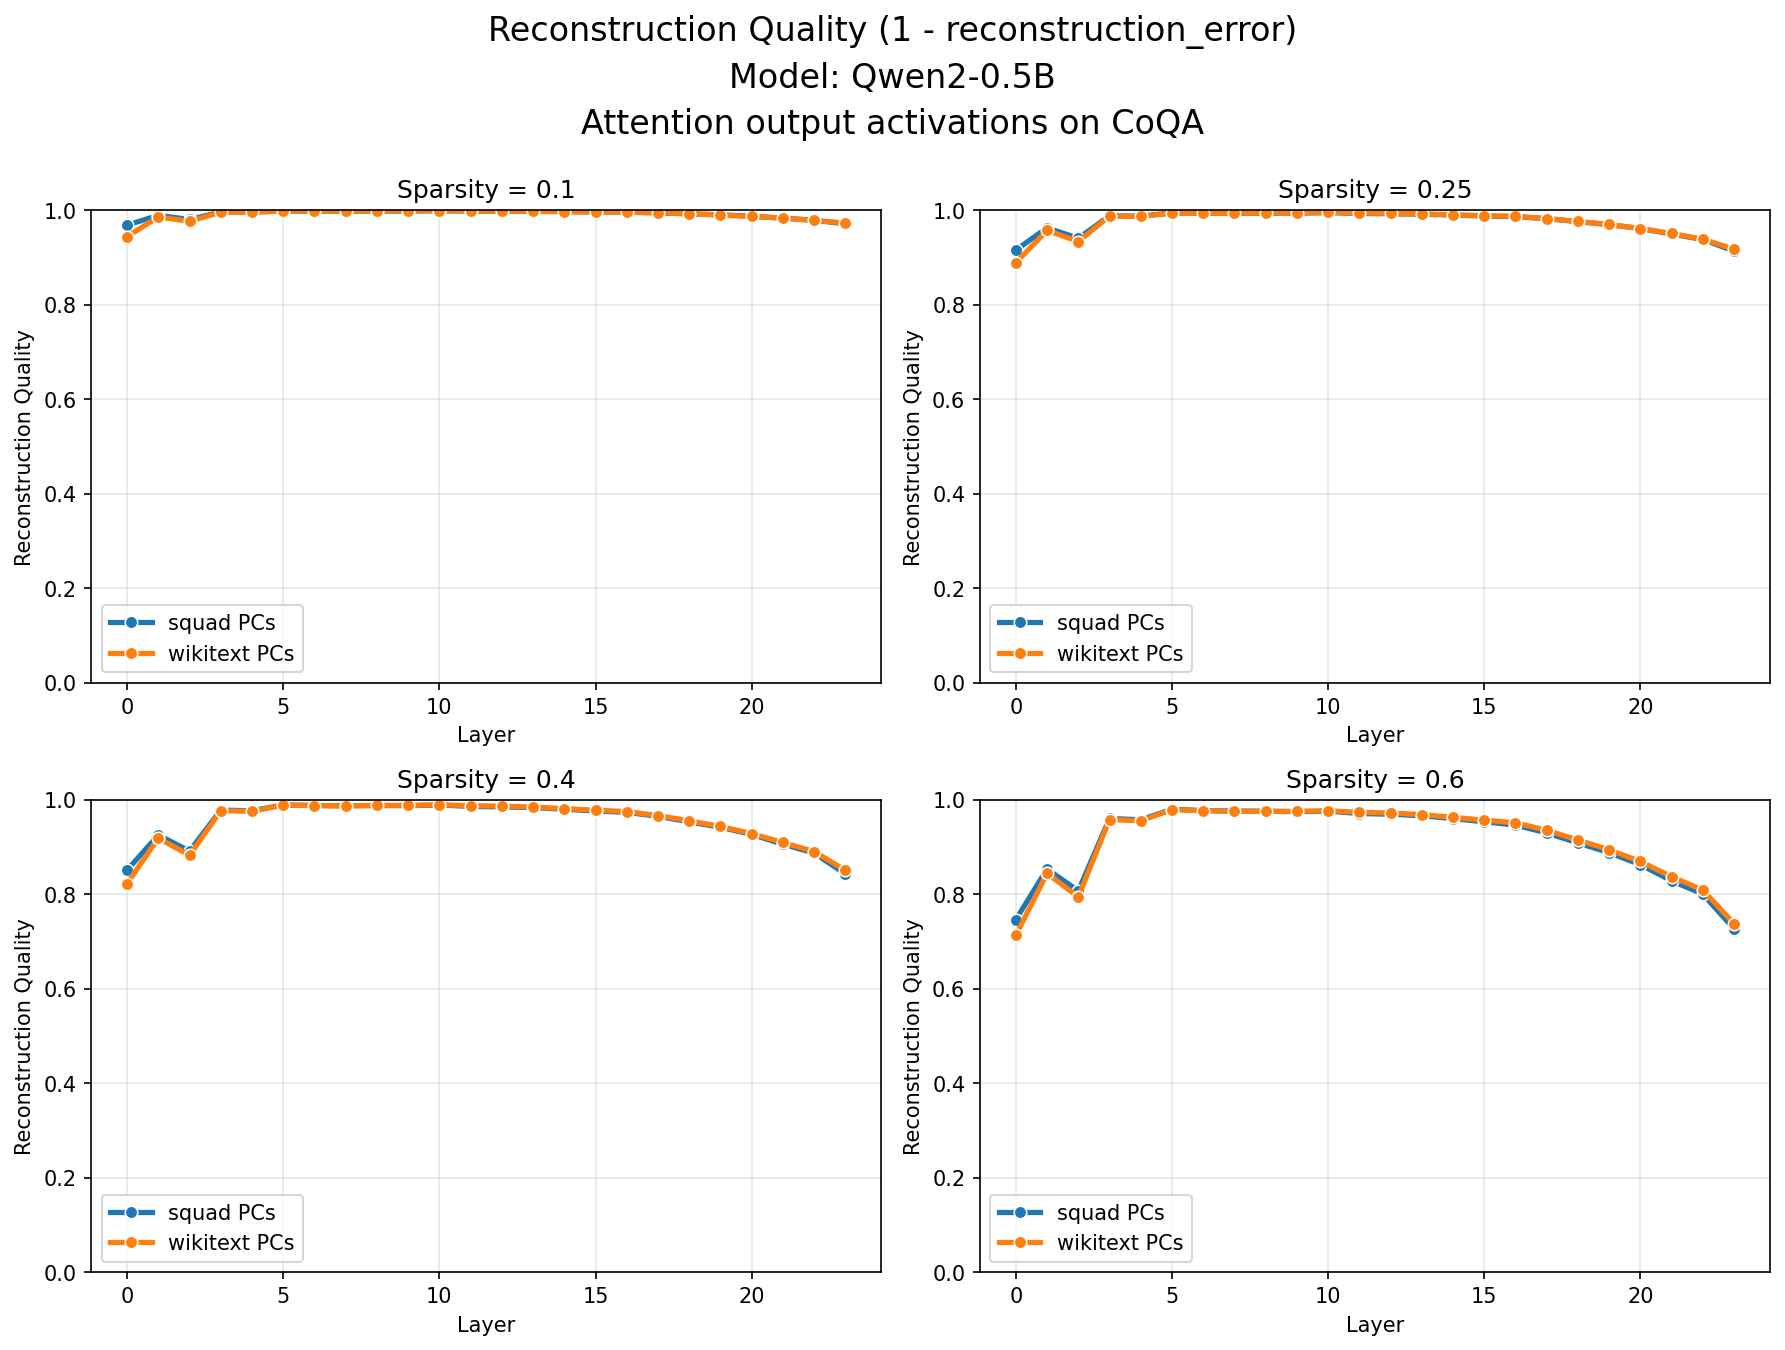

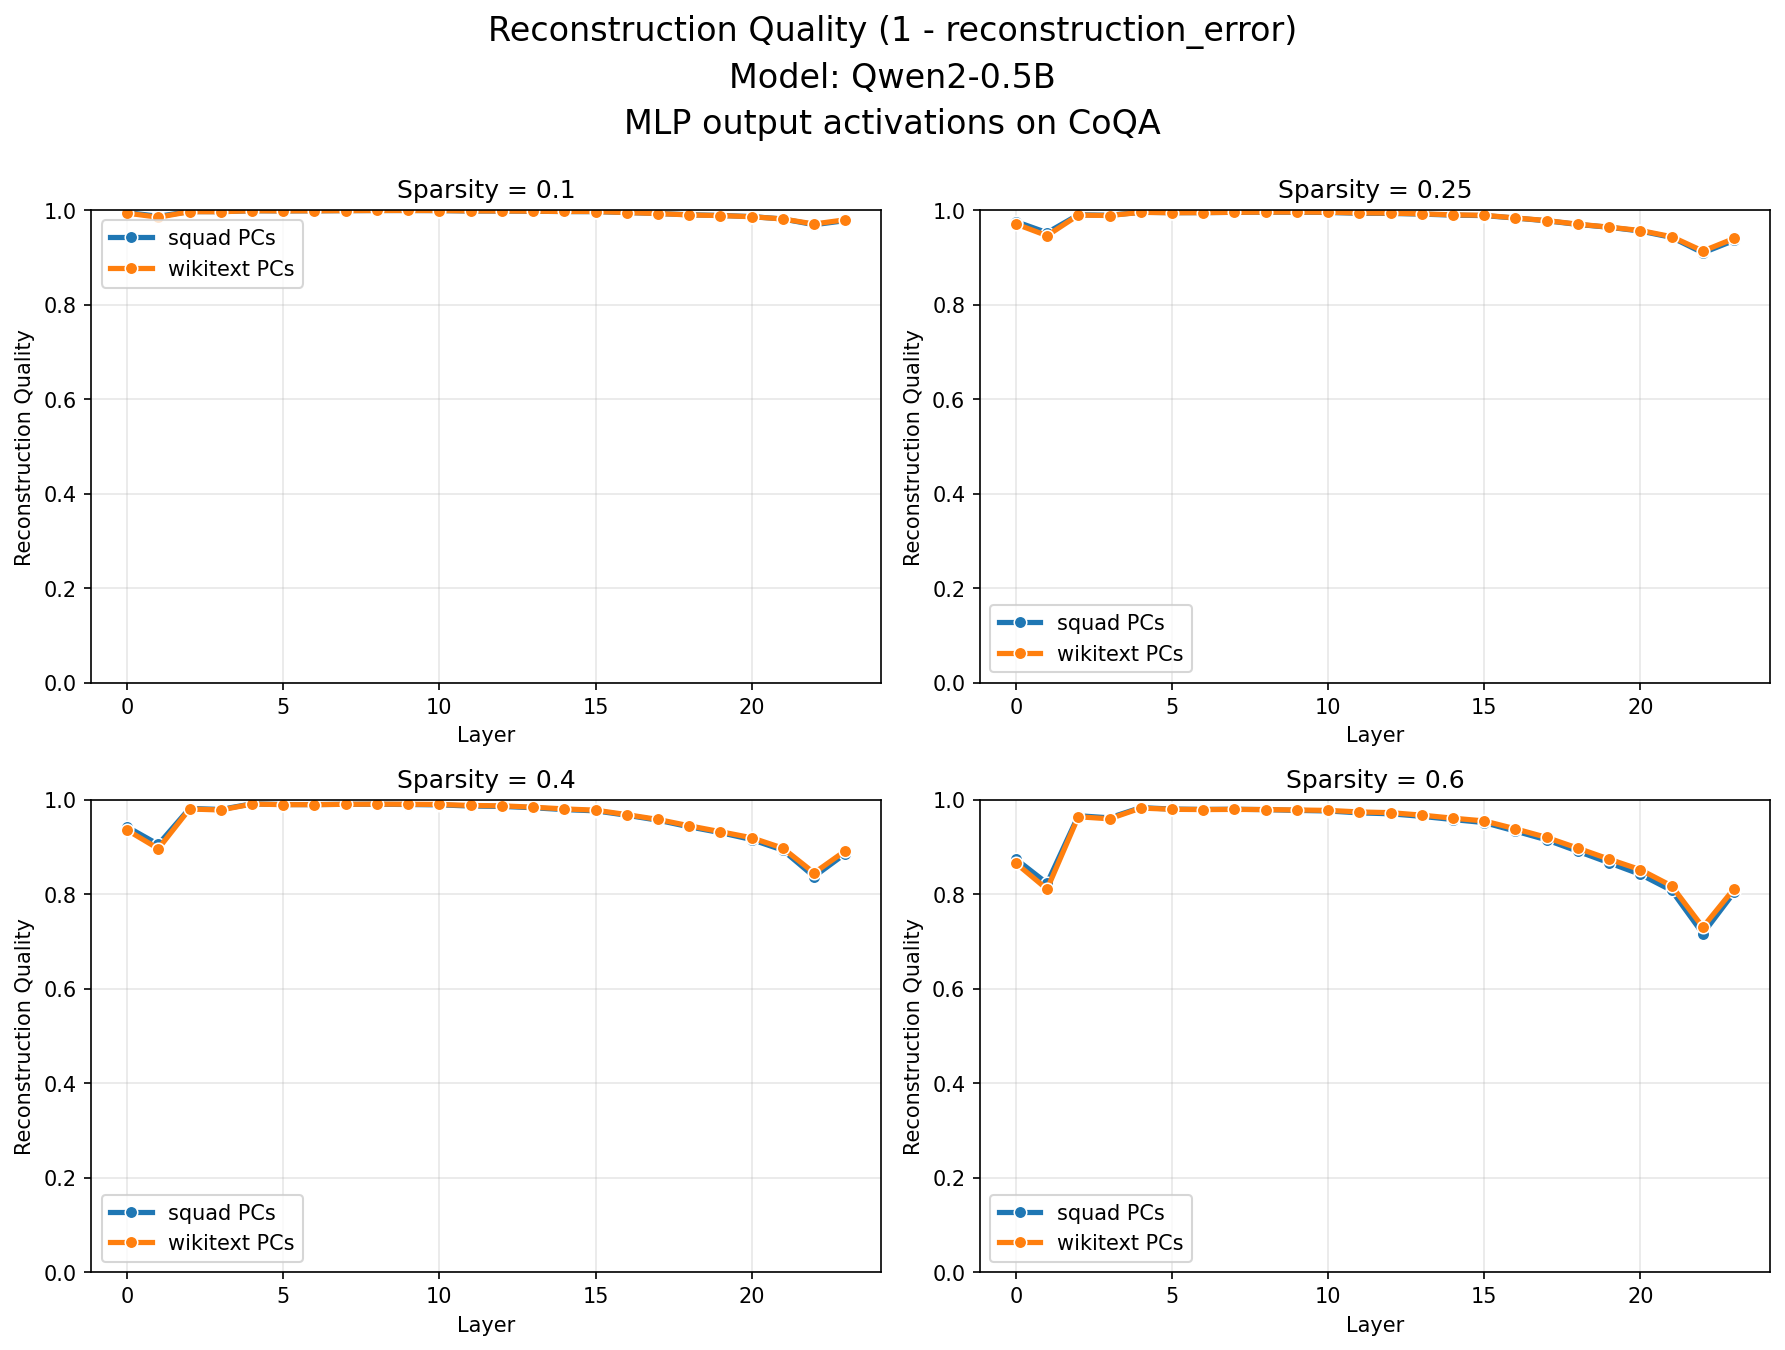

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

N_LAYERS = 24

for layer_type in ["attn_output", "mlp_output"]:

    layer_type_text = {
        "attn_output": "Attention output",
        "mlp_output": "MLP output"
        }[layer_type]

    fig, axes = plt.subplots(2, 2, figsize=(12, 9), dpi=150)
    fig.suptitle(f'Reconstruction Quality (1 - reconstruction_error)\n'
                 f'Model: {explained_variances["metadata"]["model"]}\n'
                 f'{layer_type_text} activations on CoQA',
                 fontsize=16,
                 linespacing=1.5,
                 y=0.995)

    axes = axes.flatten()

    for idx, sparsity in enumerate([0.1, 0.25, 0.4, 0.6]):
        ax = axes[idx]

        key = f"{layer_type}_{sparsity}"
        data = explained_variances[key]

        layers = range(N_LAYERS)

        sns.lineplot(x=list(range(24)),
                     y=data["coqa_to_squad"],
                     label="squad PCs",
                     marker='o',
                     linewidth=2.5,
                     ax=ax)
        sns.lineplot(x=list(range(24)),
                     y=data["coqa_to_wikitext2"],
                     label="wikitext PCs",
                     marker='o',
                     linewidth=2.5,
                     ax=ax)
        ax.set_title(f"Sparsity = {sparsity}")
        ax.set_xlabel("Layer")
        ax.set_ylabel("Reconstruction Quality")
        ax.grid(True, alpha=0.3)
        ax.set_ylim([0, 1.0])
        ax.legend()

    plt.tight_layout()
    plt.show()